In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (4,4)
plt.rcParams["axes.grid"] = False
sc.settings.set_figure_params(dpi=80, dpi_save=180, vector_friendly=True, transparent=True) #for figures

In [2]:
results= "./pnec_anndata_082023/pNEC_updated_annot_07082023.h5ad"
adata= sc.read_h5ad(results)

#Rename clusters as per main figure 1:
adata.obs['Cell states'] = (adata.obs["Cell states"].map(lambda x: {"Neuroendocrine EEC-like01": "Amphicrine progenitor-like",
                    "Neuroendocrine EEC-like02": "Neuroendocrine",
                    "Neuroendocrine HSP+": "Neuroendocrine HSP+ (hypoxic)"}.get(x, x)).astype("category"))

adata.obs['Cell states'].cat.categories

Index(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Amphicrine acinar proliferating', 'Amphicrine progenitor-like',
       'Neuroendocrine', 'Neuroendocrine proliferating',
       'Neuroendocrine HSP+ (hypoxic)', 'Neuroendocrine stromal-like',
       'Stroma (normal)', 'Lymphocytes', 'Macrophages'],
      dtype='object')

In [3]:
adata_norm= adata.raw.to_adata()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)

#Subset to shared clusters:
adata_norm_v2= adata_norm[adata_norm.obs['Cell states'].isin(['Neuroendocrine', 'Neuroendocrine proliferating',
       'Neuroendocrine HSP+ (hypoxic)', 'Neuroendocrine stromal-like', 'Stroma (normal)', 
       'Lymphocytes', 'Macrophages'])] 

print(adata_norm_v2.obs['Cell states'].value_counts())

Neuroendocrine                   10095
Neuroendocrine stromal-like       5668
Neuroendocrine proliferating      4033
Stroma (normal)                   2465
Neuroendocrine HSP+ (hypoxic)     2275
Lymphocytes                       2124
Macrophages                        821
Name: Cell states, dtype: int64


In [4]:
#Reference: Supplementary Data 2 (robust & specific markers per cluster; Logistic Regression)
#GIPR is added manually for Neuorendocrine given biological importance (we found GIPR using Wilcoxon rank sum - it's relatively enriched in P3 sample)
marker_genes = [
    "GIPR", "RBFOX1", "RIMBP2", "ADARB2", "CACNB2", "CACNA1A",
    "KCNJ3", "KCNJ6", "KCNB2", "MKI67", "DIAPH3", "CENPP",
    "EZH2", "BRCA1", "BRCA2", "BRIP1", "BARD1", "FANCI",
    "FANCA", "DTL", "ATAD5",
    "HSPA1B", "HSP90AA1", "HSP90AB1", "HSPE1", "HSPH1", "HSPD1",
    "HSPA9", "HSPA4", "DNAJB1", "NDRG1", "VEGFA", "KDM3A",
    "PFKFB4", "ERO1A", "ENO1", "GBE1", "P4HA1", "PGK1",
    "PLOD2", "ACSL3", "PSMD14",
    "ROBO2", "COL1A1", "COL1A2", "COL3A1", "CALD1", "CASC15",
    "BICC1", "CDH11", "YAP1", "WWTR1", "PDGFRA",
    "ETS1", "IKZF1", "PTPRC", "ARHGAP15", "CELF2", "DOCK2",
    "DOCK8", "PLXDC2", "ZEB2", "DPYD", "SAT1", "CTSB",
]

Trying to set attribute `._uns` of view, copying.


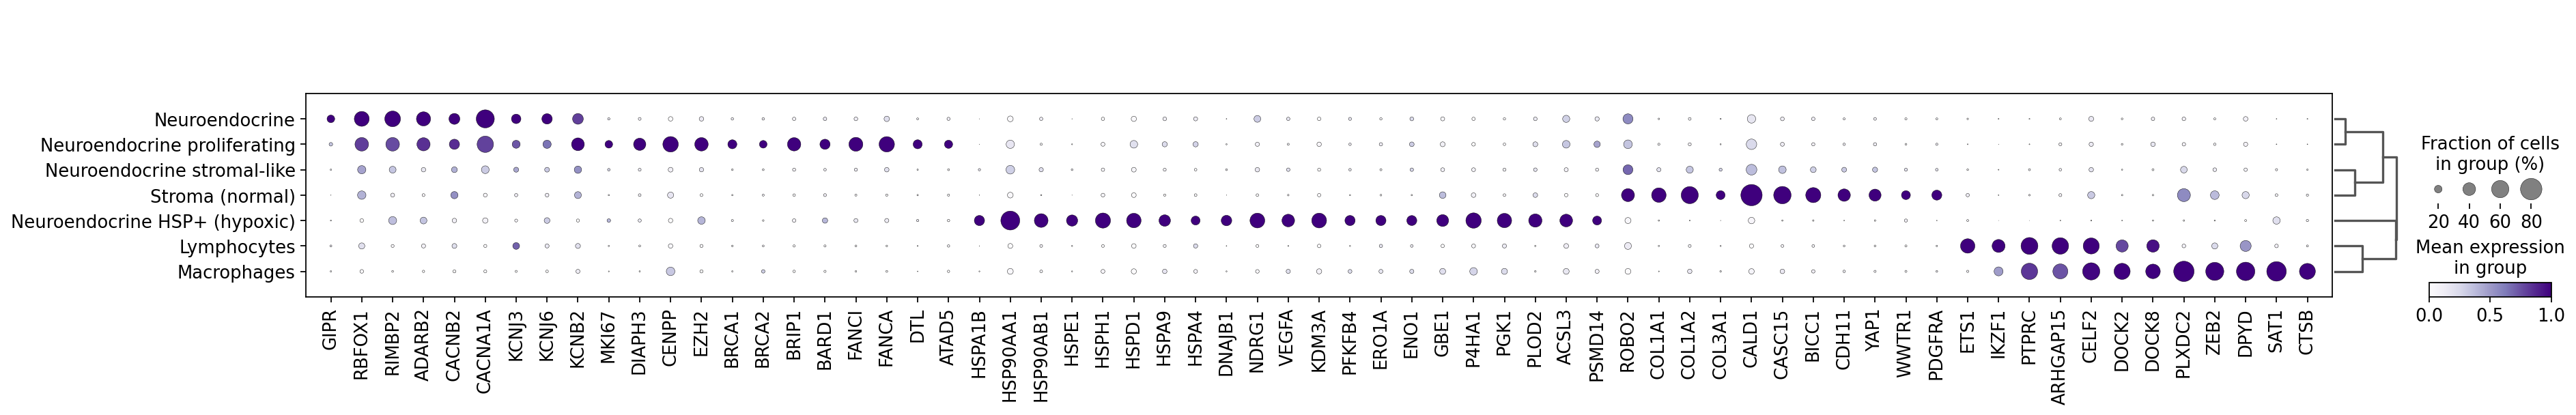

In [5]:
sc.pl.dotplot(adata_norm_v2, marker_genes, 
            groupby= "Cell states", dendrogram=True, standard_scale= "var", color_map= "Purples",
            save= "_SupplFigure3_panNEC_cellstate_markers_28112025.pdf") #